<a href="https://colab.research.google.com/github/ladybug-tentoumushi/Fashion_MNIST/blob/main/fashion_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Exploration
Let us load the libraries we are giong to use in our notebook and also dataset to display it and get grasp of the data.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
work_dir = 'drive/MyDrive/DeepLearning'

In [3]:
import torch
import numpy as np
import torch.optim as optim
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [4]:
seed = 1234
torch.manual_seed(seed)
np.random.seed(seed)

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
x_train = np.load(work_dir + '/03/data/x_train.npy')
t_train = np.load(work_dir + '/03/data/y_train.npy')
x_test = np.load(work_dir + '/03/data/x_test.npy')

class train_dataset(torch.utils.data.Dataset):
    def __init__(self, x_train, t_train):
        self.x_train = x_train.reshape(-1, 784).astype('float32') / 255
        self.t_train = t_train

    def __len__(self):
        return self.x_train.shape[0]

    def __getitem__(self, idx):
        return torch.tensor(self.x_train[idx], dtype=torch.float), torch.tensor(self.t_train[idx], dtype=torch.long)

class test_dataset(torch.utils.data.Dataset):
    def __init__(self, x_test):
        self.x_test = x_test.reshape(-1, 784).astype('float32') / 255

    def __len__(self):
        return self.x_test.shape[0]

    def __getitem__(self, idx):
        return torch.tensor(self.x_test[idx], dtype=torch.float)

trainval_data = train_dataset(x_train, t_train)
test_data = test_dataset(x_test)

In [7]:
batch_size = 32

val_size = 10000
train_size = len(trainval_data) - val_size

train_data, val_data = torch.utils.data.random_split(trainval_data, [train_size, val_size])

dataloader_train = torch.utils.data.DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=True
)

dataloader_valid = torch.utils.data.DataLoader(
    val_data,
    batch_size=batch_size,
    shuffle=False
)

dataloader_test = torch.utils.data.DataLoader(
    test_data,
    batch_size=batch_size,
    shuffle=False
)

In [8]:
def relu(x):
    x = torch.where(x > 0, x, torch.zeros_like(x))
    return x

def softmax(x):
    x -= torch.cat([x.max(axis=1, keepdim=True).values] * x.size()[1], dim=1)
    x_exp = torch.exp(x)
    return x_exp/torch.cat([x_exp.sum(dim=1, keepdim=True)] * x.size()[1], dim=1)

In [9]:
class Dense(nn.Module):
  def __init__(self, in_dim, out_dim, function=lambda x: x):
    super().__init__()
    limit = np.sqrt(6 / in_dim) # Heの一様分布
    self.W = nn.Parameter(  # nn.Parameterを使うことでWをパラメータとして渡すことができる
        torch.tensor(np.random.uniform(
            low = -limit, high = limit, size = (in_dim, out_dim)), dtype=torch.float32)
    )
    self.b = nn.Parameter(torch.tensor(np.zeros([out_dim]).astype('float32')))
    self.function = function

  def forward(self, x):
    return self.function(torch.matmul(x, self.W)+ self.b)

In [10]:
class MLP(nn.Module):
  def __init__(self, in_dim, hid_dim, out_dim):
    super().__init__()
    self.liner1 = Dense(in_dim, hid_dim, function=relu)
    self.liner2 = Dense(hid_dim, out_dim, function=softmax)

  def forward(self, x):
    x = self.liner1(x)
    x = self.liner2(x)
    return(x)

In [11]:
in_dim = 784
hid_dim = 200
out_dim = 10
lr = 0.001
batch_size = 32
n_epochs = 10


mlp = MLP(in_dim, hid_dim, out_dim).to(device)

optimizer = optim.SGD(mlp.parameters(), lr=lr)

In [12]:
# history_1: make list
history = {
    'loss': [],
    'accuracy': [],
    'val_loss': [],
    'val_accuracy': []
}

for epoch in range(n_epochs):
    losses_train = []
    losses_valid = []
    train_num = 0
    train_true_num = 0
    valid_num = 0
    valid_true_num = 0

    mlp.train()  # Training mode (compute gradients) ← nn.Module　method Dropout, Batch Norm is active
    for x, t in dataloader_train:
        # convert labels to one-hot vectors
        t_hot = torch.eye(10)[t]

        # move tensors to GPU
        x = x.to(device)
        t_hot = t_hot.to(device)

        # forward
        y = mlp(x)

        # compute loss
        loss = -(t_hot * torch.log(y + 1e-8)).sum(axis=1).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        pred = torch.argmax(y, dim=1)
        true = torch.argmax(t_hot, dim=1)

        losses_train.append(loss.tolist())

        acc = torch.where(t - pred.to("cpu") == 0, torch.ones_like(t), torch.zeros_like(t))
        train_num += acc.size()[0]
        train_true_num += acc.sum().item()

    mlp.eval()  # Eval mode (do not compute gradients)
    for x, t in dataloader_valid:
        t_hot = torch.eye(10)[t]

        x = x.to(device)
        t_hot = t_hot.to(device)

        y = mlp(x)

        loss = -(t_hot * torch.log(y + 1e-8)).sum(axis=1).mean()

        pred = torch.argmax(y, dim=1)

        losses_valid.append(loss.tolist())

        acc = torch.where(t - pred.to("cpu") == 0, torch.ones_like(t), torch.zeros_like(t))
        valid_num += acc.size()[0]
        valid_true_num += acc.sum().item()

    # history_2: calcurate every epoch mean
    train_loss = np.mean(losses_train)
    train_acc = train_true_num / train_num
    valid_loss = np.mean(losses_valid)
    valid_acc = valid_true_num / valid_num

    # history_3: save dict
    history['loss'].append(train_loss)
    history['accuracy'].append(train_acc)
    history['val_loss'].append(valid_loss)
    history['val_accuracy'].append(valid_acc)

    print('EPOCH: {}, Train [Loss: {:.3f}, Accuracy: {:.3f}], Valid [Loss: {:.3f}, Accuracy: {:.3f}]'.format(
        epoch,
        np.mean(losses_train),
        train_true_num/train_num,
        np.mean(losses_valid),
        valid_true_num/valid_num
    ))

EPOCH: 0, Train [Loss: 1.431, Accuracy: 0.574], Valid [Loss: 1.020, Accuracy: 0.696]
EPOCH: 1, Train [Loss: 0.907, Accuracy: 0.721], Valid [Loss: 0.819, Accuracy: 0.736]
EPOCH: 2, Train [Loss: 0.778, Accuracy: 0.754], Valid [Loss: 0.731, Accuracy: 0.764]
EPOCH: 3, Train [Loss: 0.711, Accuracy: 0.772], Valid [Loss: 0.679, Accuracy: 0.778]
EPOCH: 4, Train [Loss: 0.668, Accuracy: 0.785], Valid [Loss: 0.642, Accuracy: 0.787]
EPOCH: 5, Train [Loss: 0.636, Accuracy: 0.793], Valid [Loss: 0.614, Accuracy: 0.797]
EPOCH: 6, Train [Loss: 0.611, Accuracy: 0.801], Valid [Loss: 0.593, Accuracy: 0.805]
EPOCH: 7, Train [Loss: 0.592, Accuracy: 0.806], Valid [Loss: 0.575, Accuracy: 0.809]
EPOCH: 8, Train [Loss: 0.576, Accuracy: 0.811], Valid [Loss: 0.562, Accuracy: 0.812]
EPOCH: 9, Train [Loss: 0.562, Accuracy: 0.815], Valid [Loss: 0.549, Accuracy: 0.818]


In [13]:
mlp.eval()

t_pred = []
for x in dataloader_test:

    x = x.to(device)

    # Forward propagation
    y = mlp.forward(x)

    # Convert the model output to scalar class predictions
    pred = y.argmax(1).tolist()

    t_pred.extend(pred)

submission = pd.Series(t_pred, name='label')
submission.to_csv(work_dir + '/04/pred_04.csv', header=True, index_label='id')

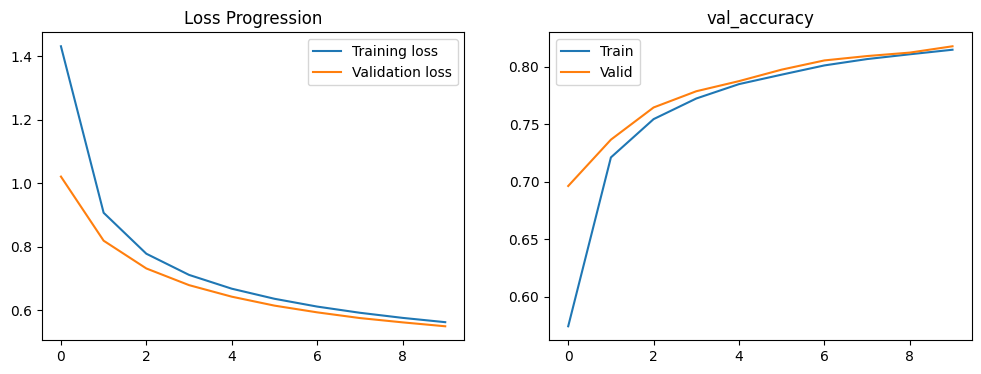

In [14]:
#1行2列でグラフを並べる例
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# 左側にLoss
ax[0].plot(history['loss'], label='Training loss')
ax[0].plot(history['val_loss'], label='Validation loss')
ax[0].set_title("Loss Progression")
ax[0].legend()

# 右側にAccuracy
ax[1].plot(history['accuracy'], label="Train")
ax[1].plot(history['val_accuracy'], label="Valid")
ax[1].set_title("val_accuracy")
ax[1].legend()

plt.show()

In [15]:
class_name = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# --- 検証データを使った最終評価 ---
val_images = []
val_true_labels = []
val_pred_labels = []

mlp.eval()
with torch.no_grad():
    for x, t in dataloader_valid: # 検証データから取り出し
        x_dev = x.to(device)
        y = mlp(x_dev)
        pred = y.argmax(1).cpu().tolist()

        val_images.extend(x.numpy())
        val_true_labels.extend(t.tolist())
        val_pred_labels.extend(pred)

val_images = np.array(val_images)

# 混合行列表示
cm = confusion_matrix(val_true_labels, val_pred_labels)
cm_df = pd.DataFrame(cm, index=[["true"]*len(class_name), class_name], columns=[["pred"]*len(class_name), class_name])
# 合計追加
cm_df[("pred", "合計")] = cm_df.sum(axis=1)
cm_df.loc[("true", "合計"), :] = cm_df.sum(axis=0)
cm_df = cm_df.astype(int)
# 表示
display(cm_df.style.background_gradient(cmap="Blues", subset=pd.IndexSlice[cm_df.index[:-1], cm_df.columns[:-1]]))

In [16]:
class_names = [f"Class {i} : {name}" for i, name in enumerate(class_name)]
print(classification_report(val_true_labels, val_pred_labels, target_names=class_names))

                      precision    recall  f1-score   support

   Class 0 : T-shirt       0.77      0.83      0.80       985
   Class 1 : Trouser       0.96      0.94      0.95       977
  Class 2 : Pullover       0.73      0.66      0.69       971
     Class 3 : Dress       0.83      0.84      0.84      1018
      Class 4 : Coat       0.69      0.75      0.72      1020
    Class 5 : Sandal       0.95      0.85      0.89       946
     Class 6 : Shirt       0.60      0.56      0.58      1039
   Class 7 : Sneaker       0.86      0.90      0.88      1020
       Class 8 : Bag       0.91      0.93      0.92      1028
Class 9 : Ankle boot       0.88      0.93      0.90       996

            accuracy                           0.82     10000
           macro avg       0.82      0.82      0.82     10000
        weighted avg       0.82      0.82      0.82     10000



総サンプル数: 10000, 誤分類数: 1824


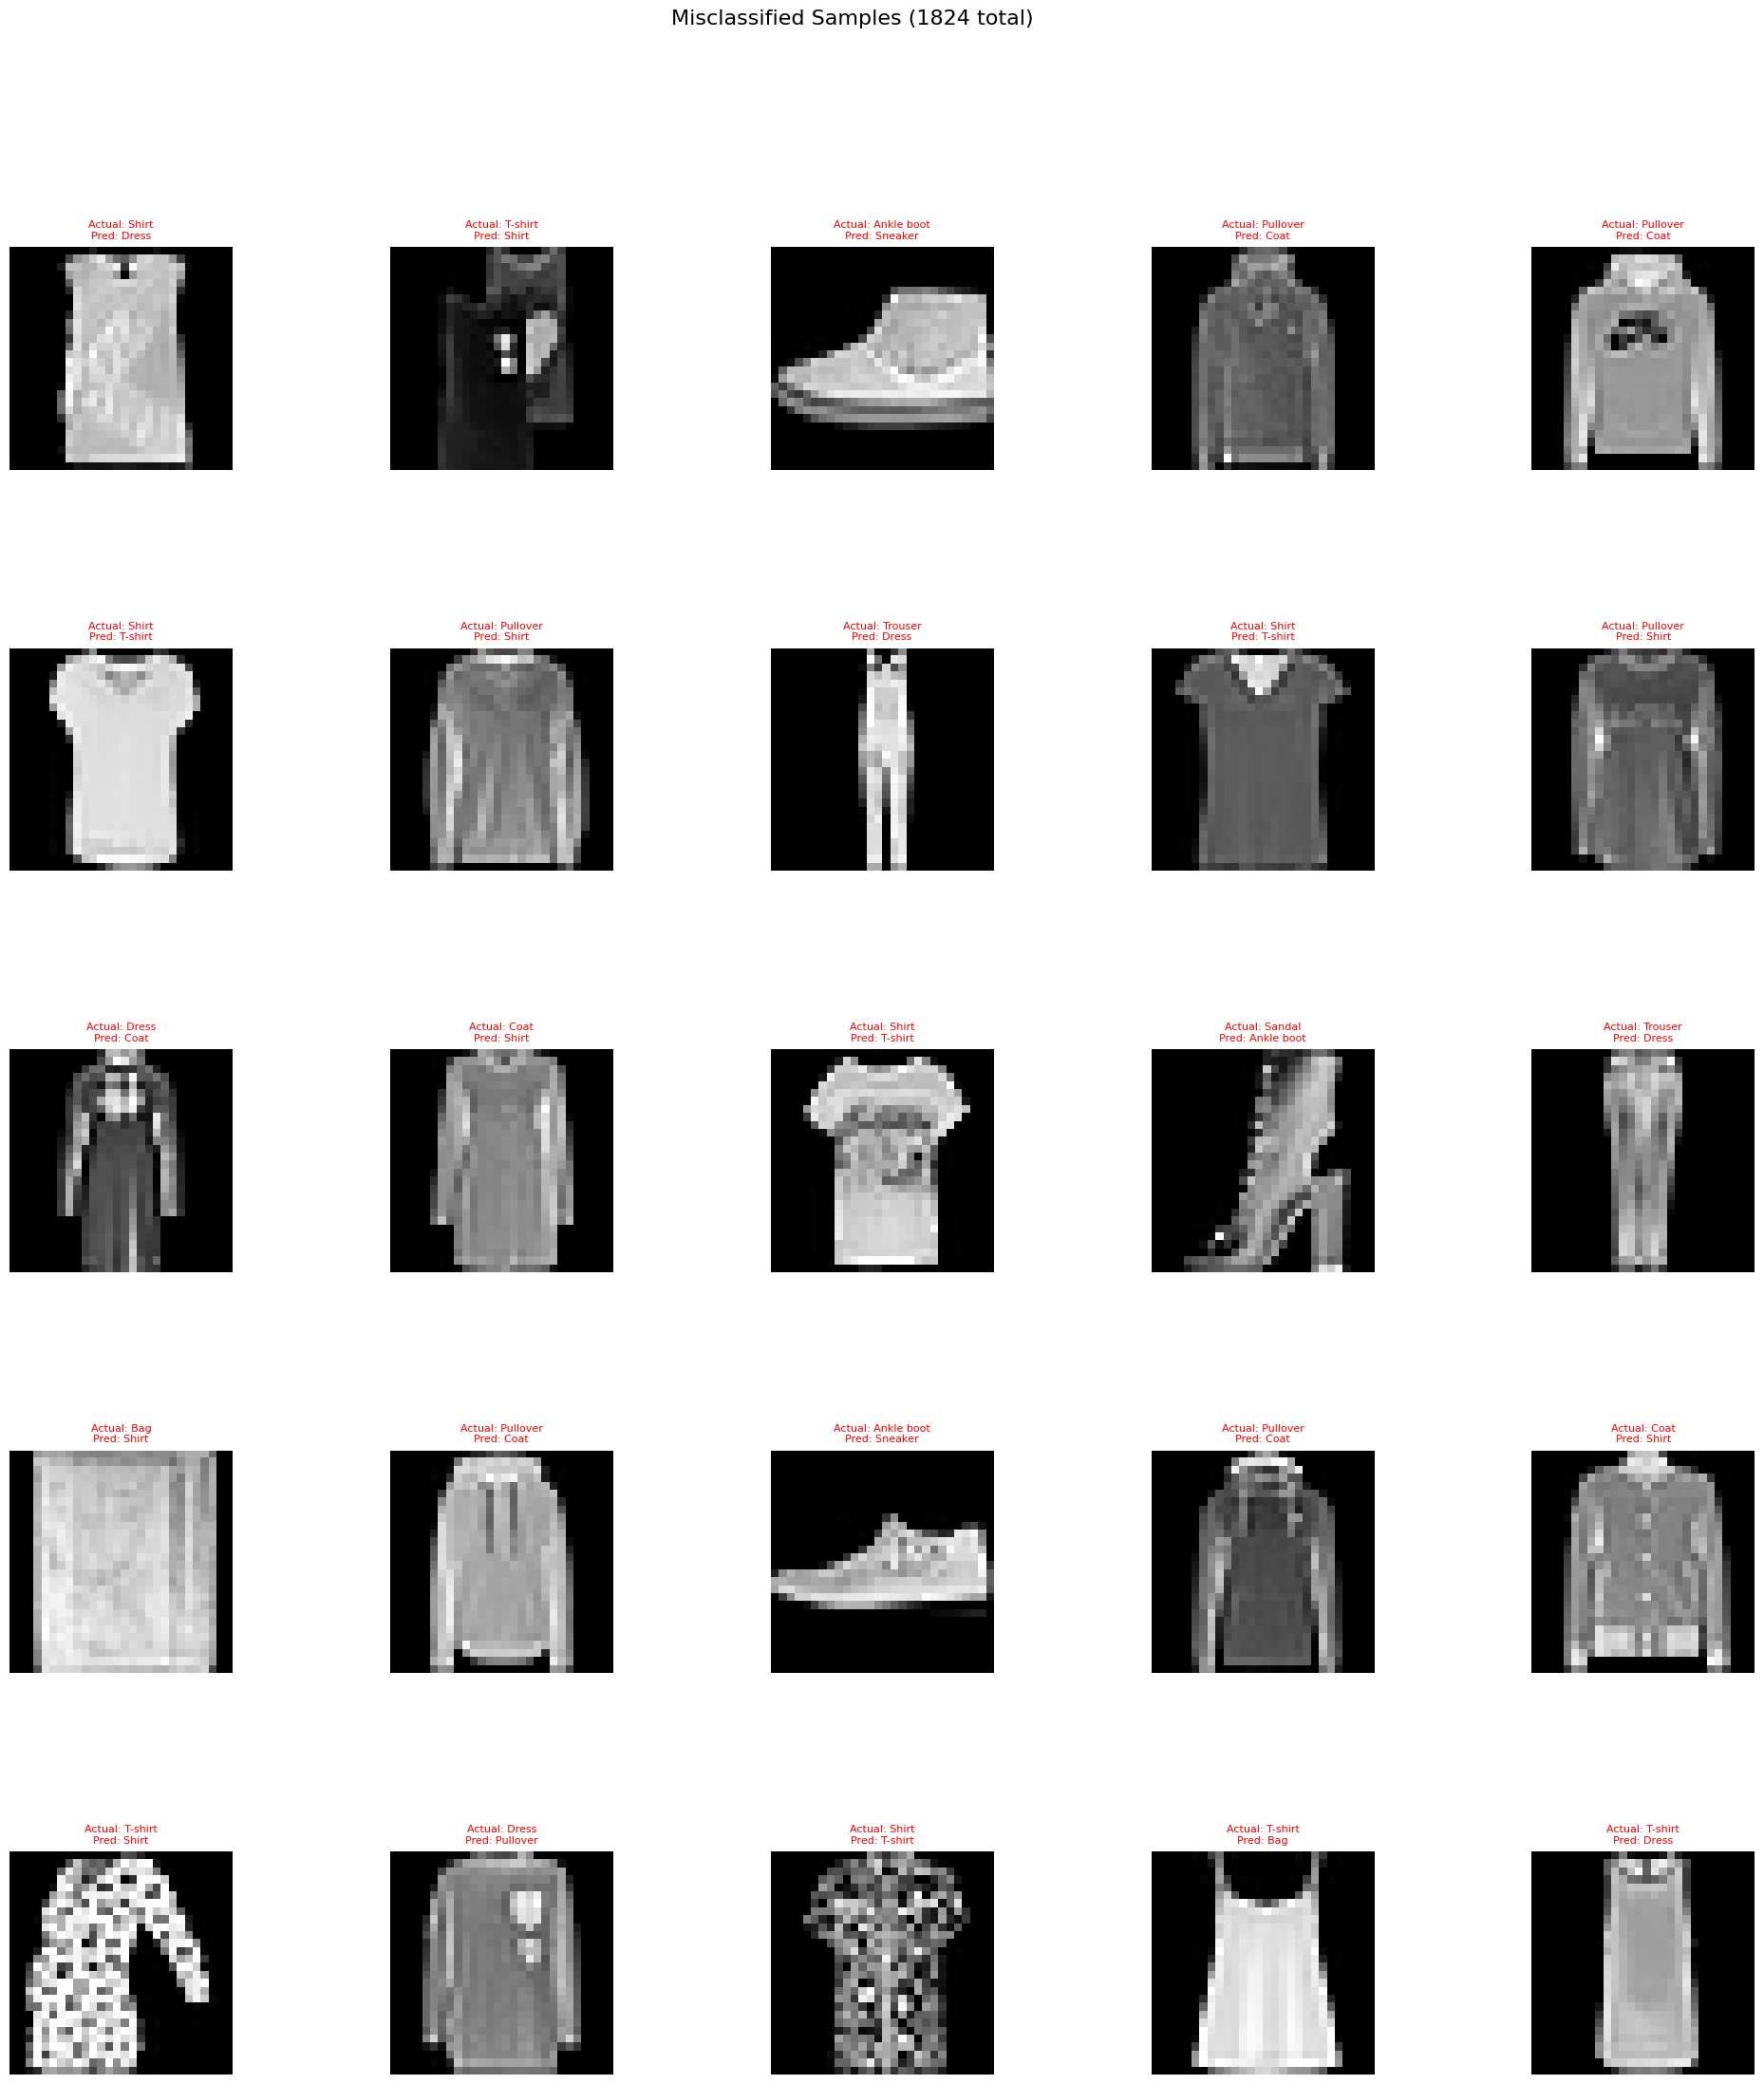

In [18]:
# --- 誤分類サンプルの可視化（検証データ） ---
wrong_indices = [i for i in range(len(val_true_labels)) if val_true_labels[i] != val_pred_labels[i]]
print(f"総サンプル数: {len(val_true_labels)}, 誤分類数: {len(wrong_indices)}")

grid_height = 5
grid_width = 5
max_display = grid_height * grid_width

fig, axes = plt.subplots(grid_height, grid_width, figsize=(25, 25))
axes = axes.ravel()

if len(wrong_indices) > 0:
    sampled = np.random.choice(wrong_indices, size=min(max_display, len(wrong_indices)), replace=False)

    for i, idx in enumerate(sampled):
        axes[i].imshow(val_images[idx].reshape(28, 28), cmap='gray')
        actual_name    = class_name[val_true_labels[idx]]
        predicted_name = class_name[val_pred_labels[idx]]
        axes[i].set_title(
            f"Actual: {actual_name}\nPred: {predicted_name}",
            fontsize=8, color='red'
        )
        axes[i].axis('off')
    # 余ったマスを非表示
    for i in range(len(sampled), max_display):
        axes[i].axis('off')
else:
    for i in range(max_display):
        axes[i].axis('off')

plt.suptitle(f"Misclassified Samples ({len(wrong_indices)} total)", fontsize=16)
plt.subplots_adjust(hspace=0.8)
plt.show()
